In [1]:
import numpy as np
import matplotlib.pyplot as plt

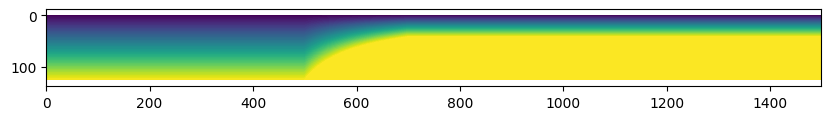

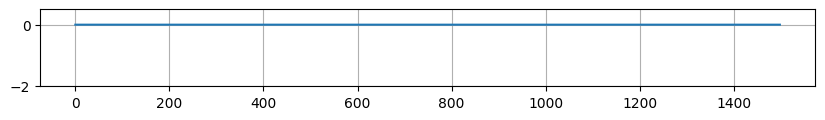

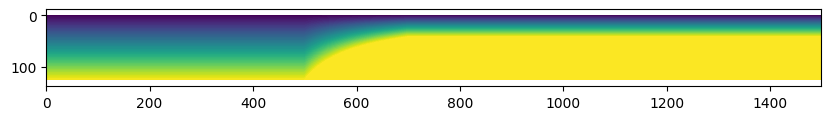

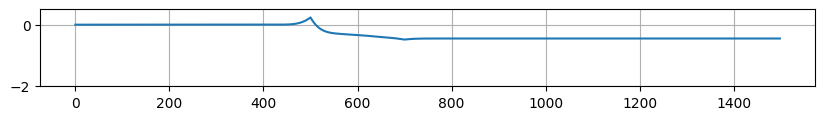

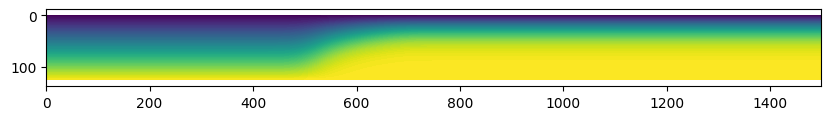

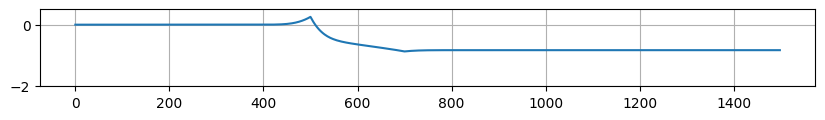

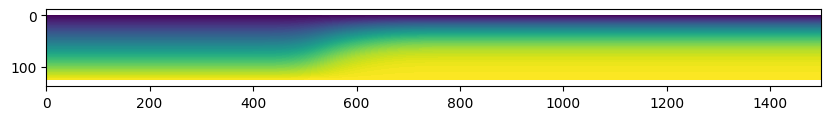

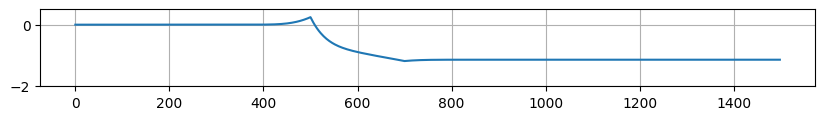

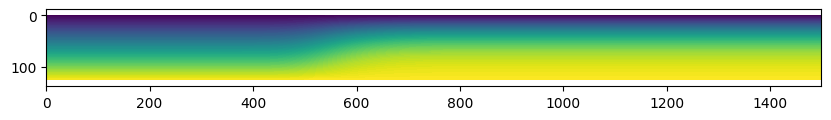

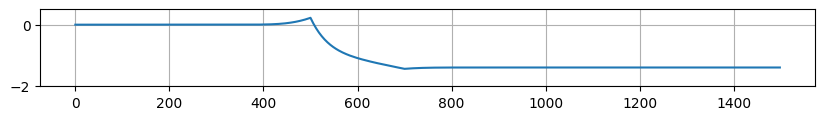

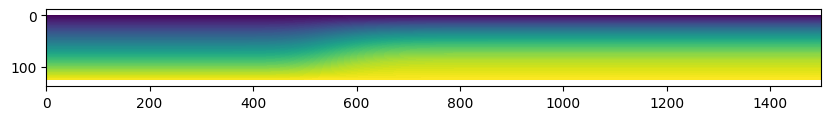

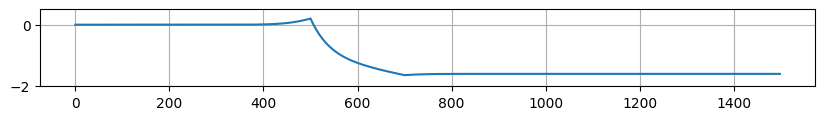

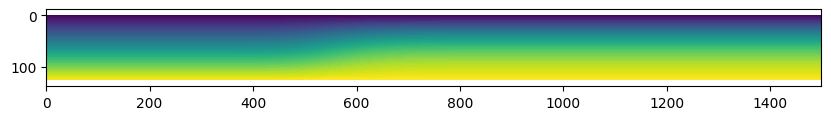

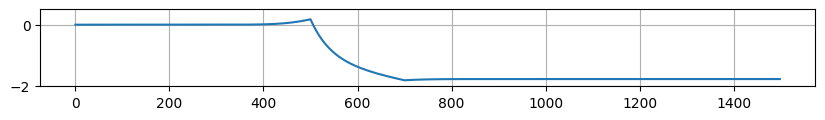

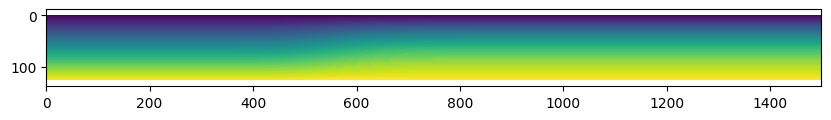

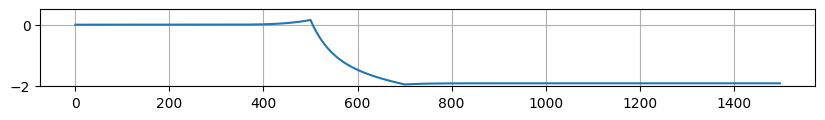

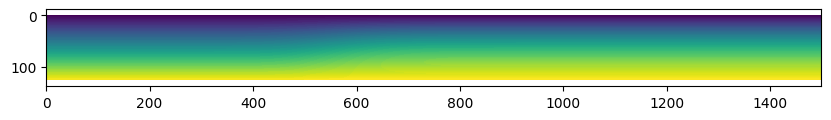

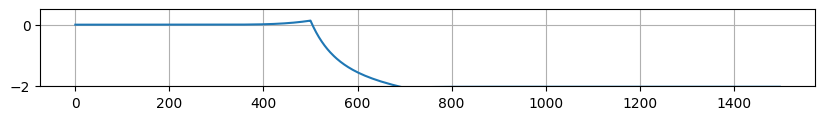

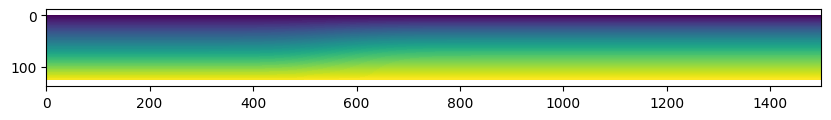

In [13]:
dx = 2000.0 # Espaçamento vertical ou horizontal
a = 125_000.0 # Espessura da litosfera
T1 = 1300.0 # Temperatura da base da litosfera

x = np.arange(0.0,1_500_000.0,dx)
z = np.arange(0.0,a,dx)

X,Z = np.meshgrid(x,z)

betamax = 3.0
beta = x*0 + 1.0

x1 = 500_000.0
x2 = 700_000.0

beta[x>=x2] = betamax
cond = (x>=x1)&(x<x2)
beta[cond] = ((x[cond]-x1)/(x2-x1))*(betamax-1.0) + 1.0

#plt.plot(x,beta)

T = Z*T1*beta/a
T[T>T1]=T1

T_inicial = np.copy(T)
Soma_T_inicial = np.sum(T_inicial,axis=0)

plt.figure(figsize=(10,1))
plt.contourf(X/1000,Z/1000,T,100)
plt.axis("equal")
plt.ylim(125,0)

t = 0.0
dt = 1000.0
kappa = 1.0E-6
seg_por_ano = 365.0*24.0*60.0*60.0

fac = kappa*dt*seg_por_ano/dx**2
t_print = 0.0

rhom = 3300.0
rhow = 1000.0
alpha = 3.28E-5

while t<81.0E6:
  T[1:-1,1:-1] += fac*(T[:-2,1:-1] + T[2:,1:-1]+
                       T[1:-1,:-2] + T[1:-1,2:]-
                       4*T[1:-1,1:-1])
  T[:,-1] = T[:,-2]
  if t>=t_print:
    Soma_T = np.sum(T,axis=0)
    plt.figure(figsize=(10,1))
    w = (Soma_T - Soma_T_inicial)*dx*alpha*rhom/(rhom-rhow)
    plt.plot(x/1000,w/1000)
    plt.ylim(-2,0.5)
    plt.grid()

    plt.figure(figsize=(10,1))
    plt.contourf(X/1000,Z/1000,T,100)
    plt.axis("equal")
    plt.ylim(125,0)
    t_print+=10.0E6
  t+=dt



In [18]:
A = np.array([[2,3],[4,5]])
print(A)

print(np.sum(A,axis=1))

[[2 3]
 [4 5]]
[5 9]
